## _(2) - Training Stage_

In [1]:
import glob, os, sys, yaml

In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
pp = pprint.PrettyPrinter(indent=2)
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

### _2.1 - Config File_

In [6]:
# load processing config file (trusted source)
config_file = os.path.join(os.curdir, 'LightningModules/GNN/configs/train_quickstart_GNN.yaml')
with open(config_file) as f:
    try:
        config = yaml.load(f, Loader=yaml.FullLoader) # equiv: yaml.full_load(f)
    except yaml.YAMLError as e:
        print(e)

### _2.2 - Input Data_

In [7]:
from LightningModules.Processing.utils.event_utils import graph_intersection
from LightningModules.Processing.utils.draw_utils import draw_proc_event, cylindrical_to_cartesian

In [8]:
# Path to feature_store, use os.path.expandvars for ${HOME}
FEATURE_DATA = os.path.expandvars(config['input_dir'])
print("FEATURE_DATA: {}".format(os.path.basename(FEATURE_DATA)))

FEATURE_DATA: feature_store


In [9]:
# examine an event, give integer value to event_id
event_id = 1
feature_data = torch.load(os.path.join(FEATURE_DATA, str(event_id)), map_location=device)
print("Length of Data: {}".format(len(feature_data)))

Length of Data: 11


In [10]:
feature_data

Data(x=[26, 3], pid=[26], layers=[26], event_file='/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000000001', hid=[26], pt=[26], modulewise_true_edges=[2, 23], layerwise_true_edges=[2, 28], edge_index=[2, 32], y=[32], cell_data=[26, 1])

In [11]:
feature_data.x[:5]

tensor([[0.1681, 0.9520, 0.3500],
        [0.1775, 0.9454, 0.3500],
        [0.1871, 0.9395, 0.3500],
        [0.1966, 0.9341, 0.3500],
        [0.2062, 0.9293, 0.3500]])

In [12]:
feature_data.cell_data[:5]

tensor([[0.0621],
        [0.1934],
        [0.2716],
        [0.3325],
        [0.3484]])

In [13]:
feature_data.y.shape

torch.Size([32])

In [14]:
type(feature_data.y)

torch.Tensor

### _2.3 - Training_

In [15]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelSummary

In [16]:
from LightningModules.GNN.Models.interaction_gnn import InteractionGNN

In [17]:
# see params used in this stage
# pp.pprint(config)

In [18]:
# change some params here
config['train_split'] = [800, 100, 100]
config['input_dir']  = os.path.join(os.environ['EXATRKX_DATA'],'run/feature_store')
config['output_dir'] = os.path.join(os.environ['EXATRKX_DATA'],'run/gnn_processed/quickstart_example')

In [19]:
# see params used in this stage
# pp.pprint(config)

- _EDA_ :: Let's test `load_event()`, it gave error

In [20]:
def select_data(events, pt_background_cut, pt_signal_cut, noise):
    """Select data after applying pt cuts OR return without applying it if pt's set to zero."""
    
    # Handle event in batched form
    if type(events) is not list:
        events = [events]

    # NOTE: Cutting background by pT BY DEFINITION removes noise
    if (pt_background_cut > 0) | (pt_signal_cut > 0):
        for event in events:

            edge_mask = (event.pt[event.edge_index] > pt_background_cut).all(0)
            event.edge_index = event.edge_index[:, edge_mask]
            event.y = event.y[edge_mask]

            if "weights" in event.__dict__.keys():
                if event.weights.shape[0] == edge_mask.shape[0]:
                    event.weights = event.weights[edge_mask]

            if (pt_signal_cut > pt_background_cut) and (
                "signal_true_edges" in event.__dict__.keys()
            ):
                signal_mask = (event.pt[event.signal_true_edges] > pt_signal_cut).all(0)
                event.signal_true_edges = event.signal_true_edges[:, signal_mask]

    return events

In [21]:
def load_dataset(input_dir, num, pt_background_cut, pt_signal_cut, noise):
    """Load data and apply pt cuts."""
    if input_dir is not None:
        all_events = os.listdir(input_dir)
        all_events = sorted([os.path.join(input_dir, event) for event in all_events])
        loaded_events = [
            torch.load(event, map_location=torch.device("cpu"))
            for event in all_events[:num]
        ]
        loaded_events = select_data(
            loaded_events, pt_background_cut, pt_signal_cut, noise
        )
        return loaded_events
    else:
        return None

    return included_edges, included_edges_mask # FIXME::ADAK: This will never execute.

In [22]:
all_events = os.listdir(config['input_dir'])

In [23]:
# init the InteractionGNN
model = InteractionGNN(config)

In [24]:
# dataset as accessed in model
model.setup(stage="fit")


Trainset: 800, Valset: 100, Testset: 100



In [25]:
trainer = Trainer(max_epochs=1)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs


In [26]:
# trainer.fit(model)

### Test Training Set

In [27]:
trainset = model.trainset

In [28]:
example_data = trainset[0]
r, phi, ir = example_data.x.T

In [29]:
x, y = r * np.cos(phi * np.pi), r * np.sin(phi * np.pi)

(Text(0.5, 1.0, 'Azimuthal View of Detector'),
 Text(0.5, 0, 'x'),
 Text(0, 0.5, 'y'))

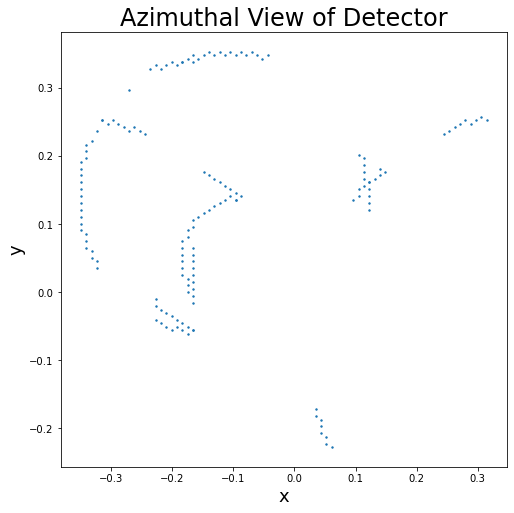

In [30]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=2)
plt.title("Azimuthal View of Detector", fontsize=24), plt.xlabel(
    "x", fontsize=18
), plt.ylabel("y", fontsize=18)

In [31]:
e = example_data.edge_index
pid = example_data.pid
true_edges = pid[e[0]] == pid[e[1]]

(Text(0.5, 1.0, 'Azimuthal View of Detector'),
 Text(0.5, 0, 'x'),
 Text(0, 0.5, 'y'))

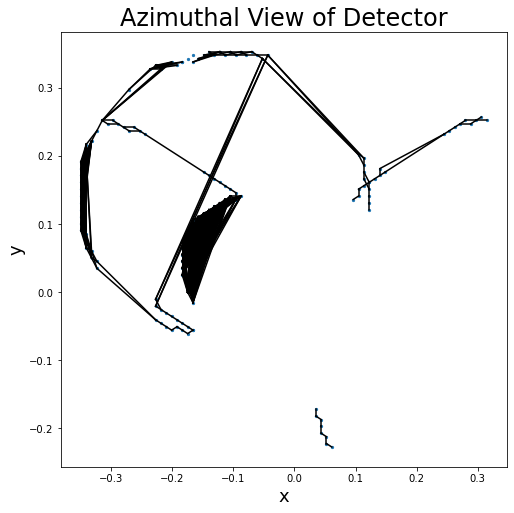

In [32]:
plt.figure(figsize=(8,8))
# plt.plot(x[e[:, ~true_edges]], y[e[:, ~true_edges]], c="r")
plt.plot(x[e[:, true_edges]], y[e[:, true_edges]], c="k")
plt.scatter(x, y, s=5)
plt.title("Azimuthal View of Detector", fontsize=24), plt.xlabel(
    "x", fontsize=18
), plt.ylabel("y", fontsize=18)

(Text(0.5, 1.0, 'Azimuthal View of Detector'),
 Text(0.5, 0, 'x'),
 Text(0, 0.5, 'y'))

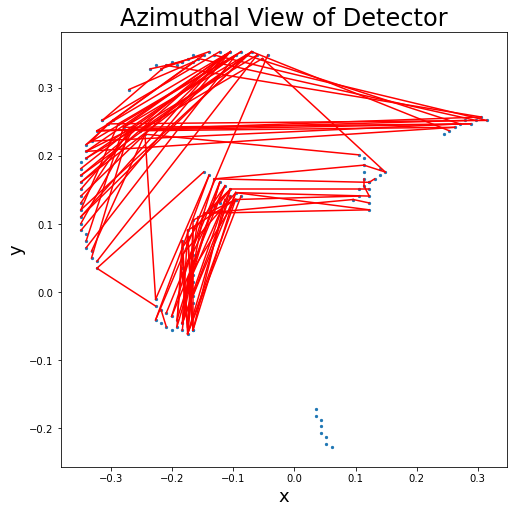

In [33]:
plt.figure(figsize=(8,8))
plt.plot(x[e[:, (~true_edges)][:, 0:-1:5]], y[e[:, (~true_edges)][:, 0:-1:5]], c="r")
plt.scatter(x, y, s=5)
plt.title("Azimuthal View of Detector", fontsize=24), plt.xlabel(
    "x", fontsize=18
), plt.ylabel("y", fontsize=18)